In [42]:
import os
os.makedirs("../images", exist_ok=True)

In [43]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

prices = pd.read_csv("../data/prices.csv", index_col=0, parse_dates=True)
returns = prices.pct_change().dropna()

n = returns.shape[1]
weights = np.ones(n) / n            # equal weights
portfolio_value = 100_000_000       # ₹10 crore

In [44]:
port_ret = returns.dot(weights)     # daily portfolio return series
var_hist_99 = -np.percentile(port_ret, 1) * portfolio_value


In [45]:
cov = returns.cov()
port_std = np.sqrt(weights @ cov.values @ weights)
var_param_99 = stats.norm.ppf(0.99) * port_std * portfolio_value
print("Hist VaR 99%:", round(var_hist_99 / portfolio_value * 100, 2), "%")
print("Parametric VaR 99%:", round(var_param_99 / portfolio_value * 100, 2), "%")

Hist VaR 99%: 2.7 %
Parametric VaR 99%: 2.48 %


In [46]:
print(port_std, port_ret.std())

0.010672080033177022 0.010672080033177022


In [61]:
returns_corr = returns.corr().round(2)
returns_corr

,HDFCBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SUNPHARMA.NS
HDFCBANK.NS,1.00,0.29,0.29,0.50,0.41,0.21
INFY.NS,0.29,1.00,0.19,0.28,0.29,0.22
ITC.NS,0.29,0.19,1.00,0.33,0.28,0.24
LT.NS,0.50,0.28,0.33,1.00,0.39,0.28
RELIANCE.NS,0.41,0.29,0.28,0.39,1.00,0.29
SUNPHARMA.NS,0.21,0.22,0.24,0.28,0.29,1.00


In [48]:
print((port_ret < -var_hist_99 / portfolio_value).sum())
print((port_ret < -var_param_99 / portfolio_value).sum())

20
25


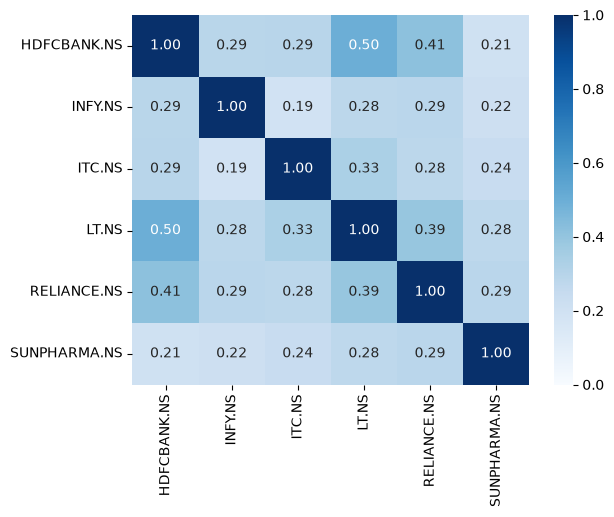

In [59]:
sns.heatmap(returns.corr(), annot=True, fmt=".2f", vmin=0, vmax=1, cmap="Blues")
plt.savefig("../images/corr_full.png", dpi=150, bbox_inches="tight")
plt.show()

In [50]:
crisis = returns.loc["2020-02-15":"2020-04-30"]
print(crisis.corr().round(2))

              HDFCBANK.NS  INFY.NS  ITC.NS  LT.NS  RELIANCE.NS  SUNPHARMA.NS
HDFCBANK.NS          1.00     0.69    0.49   0.73         0.71          0.59
INFY.NS              0.69     1.00    0.51   0.61         0.68          0.52
ITC.NS               0.49     0.51    1.00   0.56         0.48          0.50
LT.NS                0.73     0.61    0.56   1.00         0.66          0.57
RELIANCE.NS          0.71     0.68    0.48   0.66         1.00          0.63
SUNPHARMA.NS         0.59     0.52    0.50   0.57         0.63          1.00


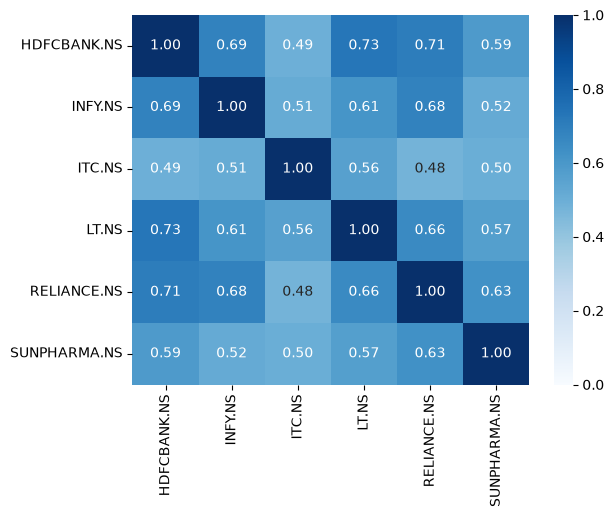

In [60]:
sns.heatmap(crisis.corr(), annot=True, fmt=".2f", vmin=0, vmax=1, cmap="Blues")
plt.savefig("../images/corr_crisis.png", dpi=150, bbox_inches="tight")
plt.show()

In [52]:
z = stats.norm.ppf(0.99)
positions = weights * portfolio_value
standalone = z * returns.std() * positions

print(standalone.round(0))
print("Sum of standalone VaRs:", round(standalone.sum()))
print("Portfolio VaR:", round(var_param_99))
print("Benefit:", round(standalone.sum() - var_param_99),
      "=", round((1 - var_param_99 / standalone.sum()) * 100, 1), "%")

HDFCBANK.NS     607060.0
INFY.NS         684548.0
ITC.NS          582705.0
LT.NS           668666.0
RELIANCE.NS     673986.0
SUNPHARMA.NS    623143.0
dtype: float64
Sum of standalone VaRs: 3840109
Portfolio VaR: 2482697
Benefit: 1357412 = 35.3 %


In [53]:
windows = {"250 days": returns.tail(250),
           "1000 days": returns.tail(1000),
           "Full history": returns}
rows = []
for name, data in windows.items():
    pr = data.dot(weights)
    hist = -np.percentile(pr, 1)
    param = stats.norm.ppf(0.99) * np.sqrt(weights @ data.cov().values @ weights)
    rows.append({"window": name, "hist %": hist * 100, "param %": param * 100})
pd.DataFrame(rows).round(2)

,window,hist %,param %
0,250 days,2.15,2.00
1,1000 days,1.99,1.89
2,Full history,2.70,2.48


In [54]:
# 1) Crisis diversification benefit
crisis = returns.loc["2020-02-15":"2020-04-30"]
standalone_c = z * crisis.std() * positions
port_c = z * np.sqrt(weights @ crisis.cov().values @ weights) * portfolio_value
print("Crisis benefit:", round((1 - port_c / standalone_c.sum()) * 100, 1), "%")

Crisis benefit: 18.3 %


In [55]:
# 2) Is the 250-day window higher due to volatility or correlation?
for name, data in windows.items():
    c = data.corr().values
    avg_corr = c[np.triu_indices_from(c, k=1)].mean()
    print(name, "| avg stock vol %:", round(data.std().mean() * 100, 2),
          "| avg correlation:", round(avg_corr, 2))

250 days | avg stock vol %: 1.43 | avg correlation: 0.23
1000 days | avg stock vol %: 1.34 | avg correlation: 0.24
Full history | avg stock vol %: 1.65 | avg correlation: 0.3


In [56]:
vol_by_window = pd.DataFrame({name: data.std() * 100 for name, data in windows.items()})
print(vol_by_window.round(2))

              250 days  1000 days  Full history
HDFCBANK.NS       1.34       1.25          1.57
INFY.NS           1.89       1.62          1.77
ITC.NS            1.29       1.18          1.50
LT.NS             1.57       1.51          1.72
RELIANCE.NS       1.29       1.29          1.74
SUNPHARMA.NS      1.21       1.18          1.61


In [57]:
n = 6
for name, data in windows.items():
    c = data.corr().values
    rho = c[np.triu_indices_from(c, k=1)].mean()
    vol = data.std().mean()
    print(name, round(z * vol * np.sqrt(1/n + (1 - 1/n) * rho) * 100, 2))

250 days 1.99
1000 days 1.88
Full history 2.48


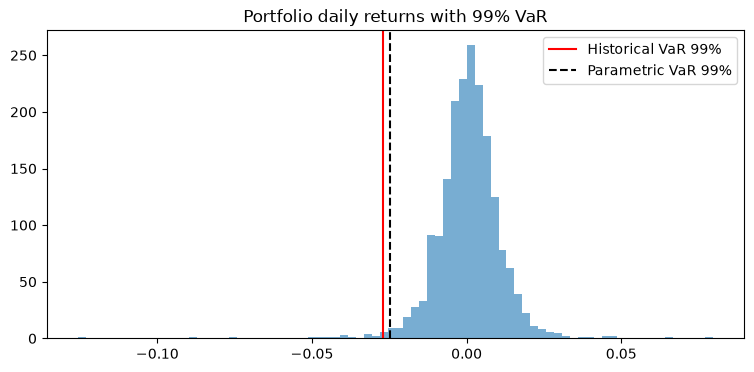

In [58]:
plt.figure(figsize=(9, 4))
plt.hist(port_ret, bins=80, alpha=0.6)
plt.axvline(-var_hist_99 / portfolio_value, color="red", label="Historical VaR 99%")
plt.axvline(-var_param_99 / portfolio_value, color="black", linestyle="--", label="Parametric VaR 99%")
plt.legend(); plt.title("Portfolio daily returns with 99% VaR")
plt.savefig("../images/portfolio_var_hist.png", dpi=150, bbox_inches="tight")
plt.show()